In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dense,
    BatchNormalization,
    GlobalAveragePooling1D,
    Dropout,
    Add,
    Input
)

from keras.models import Model

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    matthews_corrcoef
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/ecg_datasets/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/ecg_datasets/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


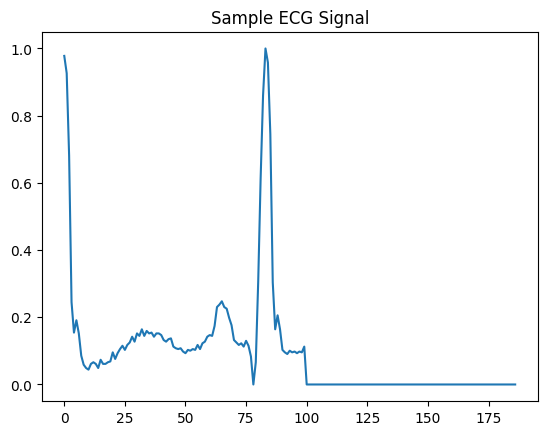

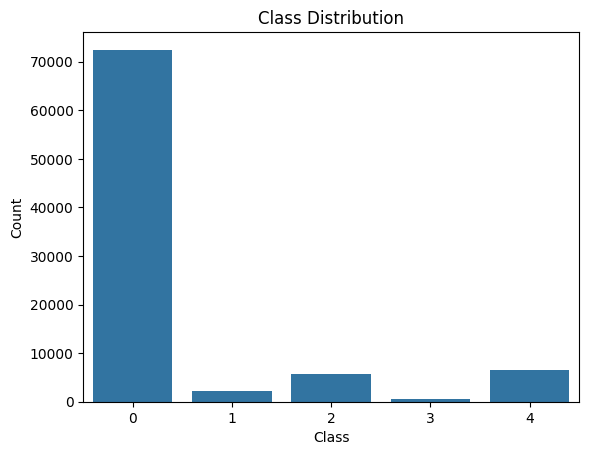

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()

sns.barplot(
    x=[0,1,2,3,4],
    y=counts.values
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [6]:
print("Train Missing:", train.isna().sum().sum())
print("Test Missing :", test.isna().sum().sum())

Train Missing: 0
Test Missing : 0


In [7]:
X_train = train.iloc[:, :-1].values
y_train = train.iloc[:, -1].values

X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values

X_test = X_test.reshape(-1, 187, 1)

y_test_cat = to_categorical(y_test, 5)

In [8]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(
        filters,
        3,
        strides=stride,
        padding='same'
    )(x)

    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(
        filters,
        3,
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:

        shortcut = Conv1D(
            filters,
            1,
            strides=stride,
            padding='same'
        )(shortcut)

        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])

    x = tf.keras.layers.Activation('relu')(x)

    return x

In [9]:
def poly1_loss(
    y_true,
    y_pred,
    epsilon=1.0
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.clip_by_value(
        y_pred,
        1e-7,
        1.0 - 1e-7
    )

    ce = tf.keras.losses.categorical_crossentropy(
        y_true,
        y_pred
    )

    pt = tf.reduce_sum(
        y_true * y_pred,
        axis=-1
    )

    poly1 = ce + epsilon * (1 - pt)

    return tf.reduce_mean(poly1)

In [10]:
def resnet_ecg():

    inputs = Input(
        shape=(187,1)
    )

    x = Conv1D(
        32,
        3,
        activation='relu'
    )(inputs)

    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        5,
        activation='softmax'
    )(x)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer='adam',
        loss=poly1_loss,
        metrics=['accuracy']
    )

    return model

In [11]:
kfold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(
    kfold.split(X_train, y_train)
):

    print(f"\nFold {fold+1}")

    X_tr = X_train[train_idx]
    y_tr = y_train[train_idx]

    X_va = X_train[val_idx]
    y_va = y_train[val_idx]

    smote = SMOTE(
        random_state=42
    )

    X_tr, y_tr = smote.fit_resample(
        X_tr,
        y_tr
    )

    X_tr = X_tr.reshape(-1,187,1)
    X_va = X_va.reshape(-1,187,1)

    y_tr = to_categorical(y_tr,5)
    y_va = to_categorical(y_va,5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(
        X_va,
        y_va,
        verbose=0
    )

    print(
        f"Fold {fold+1} Accuracy: {acc:.4f}"
    )

    cv_accuracies.append(acc)

print("\nCV Accuracies:", cv_accuracies)
print("Mean CV:", np.mean(cv_accuracies))
print("Std CV :", np.std(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 56s 10ms/step - accuracy: 0.9366 - loss: 0.2754
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9749 - loss: 0.1138
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9836 - loss: 0.0754
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9885 - loss: 0.0535
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9913 - loss: 0.0403
Fold 1 Accuracy: 0.9761

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.9371 - loss: 0.2774
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9752 - loss: 0.1152
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9846 - loss: 0.0731
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9885 - loss: 0.0536
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9911 - loss: 0.0418
Fold 2 Accuracy: 0.9765

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 51s 1

In [12]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

smote = SMOTE(
    random_state=42
)

X_train_final, y_train_final = smote.fit_resample(
    X_train_final,
    y_train_final
)

X_train_final = X_train_final.reshape(
    -1,
    187,
    1
)

X_val_final = X_val_final.reshape(
    -1,
    187,
    1
)

y_train_final = to_categorical(
    y_train_final,
    5
)

y_val_final = to_categorical(
    y_val_final,
    5
)

In [13]:
model = resnet_ecg()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(
        X_val_final,
        y_val_final
    ),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 63s 11ms/step - accuracy: 0.9428 - loss: 0.2529 - val_accuracy: 0.9569 - val_loss: 0.2069
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9788 - loss: 0.0971 - val_accuracy: 0.9409 - val_loss: 0.2773
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9862 - loss: 0.0646 - val_accuracy: 0.9770 - val_loss: 0.1415
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9898 - loss: 0.0477 - val_accuracy: 0.9588 - val_loss: 0.2181
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9923 - loss: 0.0367 - val_accuracy: 0.9606 - val_loss: 0.3123
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9938 - loss: 0.0300 - val_accuracy: 0.9753 - val_loss: 0.1366
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9949 - loss: 0.0251 - val_accuracy: 0.8970 - val_loss: 1.2299
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9954 - loss: 

In [14]:
y_val_pred = np.argmax(
    model.predict(X_val_final),
    axis=1
)

y_val_true = np.argmax(
    y_val_final,
    axis=1
)

mcc_val = matthews_corrcoef(
    y_val_true,
    y_val_pred
)

print(
    "Validation MCC:",
    mcc_val
)

548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Validation MCC: 0.9204517015850657


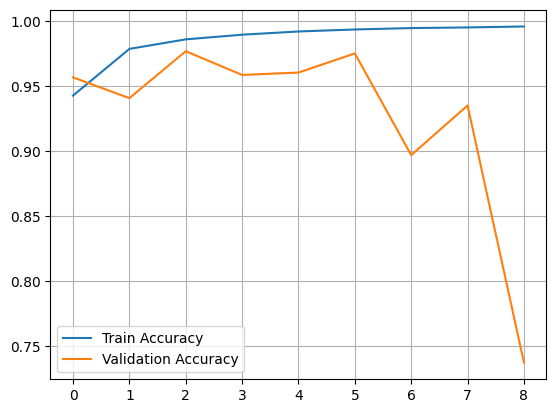

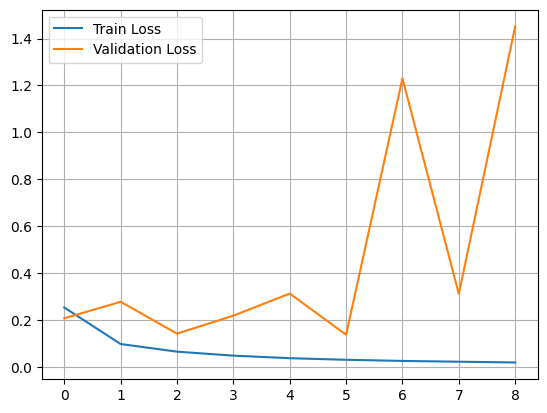

In [15]:
plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()
plt.grid()
plt.show()


plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()
plt.grid()
plt.show()

In [16]:
train_loss, train_acc = model.evaluate(
    X_train_final,
    y_train_final,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val_final,
    y_val_final,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Train Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)
print("Test Accuracy :", test_acc)

Train Accuracy : 0.9955741167068481
Validation Accuracy : 0.9753298163414001
Test Accuracy : 0.9755162000656128


In [18]:
y_test_pred = np.argmax(
    model.predict(X_test),
    axis=1
)

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     18118
         1.0       0.70      0.75      0.72       556
         2.0       0.96      0.95      0.96      1448
         3.0       0.66      0.88      0.75       162
         4.0       0.98      0.99      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.86      0.91      0.88     21892
weighted avg       0.98      0.98      0.98     21892



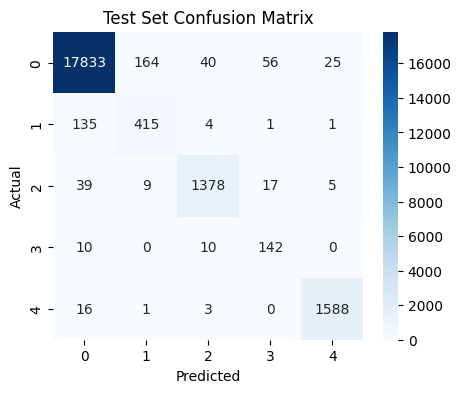

In [19]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix")

plt.show()